# 🍔 Online Food Delivery Data Analysis

---

| Field | Details |
|---|---|
| **Student Name** | Krati Neema |
| **Project Title** | Online Food Delivery Data Analysis |
| **Tool Used** | Python, Pandas, NumPy, Matplotlib, Seaborn |
| **Dataset** | Online Food Delivery Dataset (Kaggle) |

---

## 📌 Project Objective
Analyze food delivery orders, delivery times, customer ratings, and restaurant performance to uncover meaningful patterns and insights from real-world data.

---
## Section 1 — Import Libraries
We begin by importing all necessary Python libraries used throughout this analysis.

In [29]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Settings for better-looking plots
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

# Suppress unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## Section 2 — Load Dataset



In [30]:
# ----- Option A: Load from uploaded file in Colab -----
# df = pd.read_csv('food_delivery.csv')

# ----- Option B: Generate sample dataset

np.random.seed(42)
n = 500

restaurants = ['Dominos', 'McDonalds', 'KFC', 'Pizza Hut', 'Subway',
               'Burger King', 'Barbeque Nation', 'Haldirams', 'Behrouz Biryani', 'Faasos']
cities       = ['Mumbai', 'Delhi', 'Bangalore', 'Hyderabad', 'Pune', 'Chennai']
categories   = ['Fast Food', 'Biryani', 'Pizza', 'Burger', 'Desserts', 'Chinese', 'North Indian']
payment_modes= ['Cash', 'UPI', 'Credit Card', 'Debit Card']

df = pd.DataFrame({
    'Order_ID'          : range(1001, 1001 + n),
    'Restaurant_Name'   : np.random.choice(restaurants, n),
    'City'              : np.random.choice(cities, n),
    'Category'          : np.random.choice(categories, n),
    'Order_Amount'      : np.round(np.random.uniform(80, 1200, n), 2),
    'Delivery_Time_mins': np.random.choice(list(range(15, 75)) + [None]*30, n),
    'Customer_Rating'   : np.random.choice([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, None], n),
    'Payment_Mode'      : np.random.choice(payment_modes, n),
    'Is_Late_Delivery'  : np.random.choice([0, 1], n, p=[0.72, 0.28]),
    'Order_Month'       : np.random.choice(['Jan','Feb','Mar','Apr','May','Jun',
                                            'Jul','Aug','Sep','Oct','Nov','Dec'], n)
})

# Introduce some duplicates and nulls to simulate real-world messiness
df = pd.concat([df, df.sample(10)], ignore_index=True)
df.loc[np.random.choice(df.index, 15), 'Restaurant_Name'] = None

print(f'✅ Dataset loaded successfully!')
print(f'   Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

✅ Dataset loaded successfully!
   Shape: 510 rows × 10 columns


,Order_ID,Restaurant_Name,City,Category,Order_Amount,Delivery_Time_mins,Customer_Rating,Payment_Mode,Is_Late_Delivery,Order_Month
0,1001,Barbeque Nation,Mumbai,Pizza,930.12,19,5.0,Cash,0,Jun
1,1002,Pizza Hut,Chennai,Pizza,891.00,62,1.5,Cash,0,Mar
2,1003,Haldirams,Mumbai,Fast Food,793.70,51,3.0,Cash,0,Sep
3,1004,Subway,Mumbai,Chinese,1178.25,None,3.0,Cash,1,May
4,1005,Barbeque Nation,Chennai,Burger,1091.77,58,4.5,Cash,0,Aug
5,1006,Faasos,Hyderabad,Desserts,804.26,29,4.5,Debit Card,1,Jul
6,1007,KFC,Mumbai,Pizza,856.36,57,4.0,Credit Card,0,Aug
7,1008,Barbeque Nation,Chennai,Fast Food,137.79,62,4.0,Cash,0,Jul
8,1009,Haldirams,Pune,Desserts,830.31,None,3.5,UPI,0,Mar
9,1010,Subway,Bangalore,Chinese,129.47,None,3.5,Debit Card,0,Feb


---
## Section 3 — Data Exploration

Before cleaning, we explore the raw dataset to understand its structure, data types, and basic statistics.

In [31]:
# Dataset dimensions
print('='*45)
print(f'  Total Rows    : {df.shape[0]}')
print(f'  Total Columns : {df.shape[1]}')
print('='*45)

  Total Rows    : 510
  Total Columns : 10


In [32]:
# Column names, data types, and non-null counts
print('--- Dataset Info ---')
df.info()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order_ID            510 non-null    int64  
 1   Restaurant_Name     495 non-null    object 
 2   City                510 non-null    object 
 3   Category            510 non-null    object 
 4   Order_Amount        510 non-null    float64
 5   Delivery_Time_mins  361 non-null    object 
 6   Customer_Rating     464 non-null    object 
 7   Payment_Mode        510 non-null    object 
 8   Is_Late_Delivery    510 non-null    int64  
 9   Order_Month         510 non-null    object 
dtypes: float64(1), int64(2), object(7)
memory usage: 40.0+ KB


In [33]:
# Statistical summary for numerical columns
print('--- Statistical Summary ---')
df.describe().round(2)

--- Statistical Summary ---


,Order_ID,Order_Amount,Is_Late_Delivery
count,510.00,510.00,510.00
mean,1250.32,647.18,0.30
std,144.62,324.44,0.46
min,1001.00,80.27,0.00
25%,1124.25,365.03,0.00
50%,1251.50,666.63,0.00
75%,1376.75,917.05,1.00
max,1500.00,1199.28,1.00


In [34]:
# Check missing values in each column
print('--- Missing Values ---')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

--- Missing Values ---
                    Missing Count  Missing %
Restaurant_Name                15       2.94
Delivery_Time_mins            149      29.22
Customer_Rating                46       9.02


In [35]:
# Check for duplicate rows
dupes = df.duplicated().sum()
print(f'Duplicate rows found: {dupes}')

Duplicate rows found: 8


---
## Section 4 — Data Cleaning & Preprocessing

We handle missing values, remove duplicates, and fix data types to prepare a clean dataset for analysis.

In [36]:
# Step 1: Remove duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f'Duplicates removed : {before - after} rows')
print(f'Remaining rows     : {after}')

Duplicates removed : 8 rows
Remaining rows     : 502


In [37]:
# Step 2: Handle missing values

# Fill missing Delivery_Time_mins with the median (robust to outliers)
median_time = df['Delivery_Time_mins'].median()
df['Delivery_Time_mins'].fillna(median_time, inplace=True)
print(f'Delivery_Time_mins → filled nulls with median: {median_time:.1f} mins')

# Fill missing Customer_Rating with the mean rating
mean_rating = df['Customer_Rating'].mean()
df['Customer_Rating'].fillna(round(mean_rating, 1), inplace=True)
print(f'Customer_Rating    → filled nulls with mean : {mean_rating:.2f}')

# Fill missing Restaurant_Name with 'Unknown'
df['Restaurant_Name'].fillna('Unknown', inplace=True)
print('Restaurant_Name    → filled nulls with "Unknown"')

Delivery_Time_mins → filled nulls with median: 43.0 mins
Customer_Rating    → filled nulls with mean : 3.07
Restaurant_Name    → filled nulls with "Unknown"


In [38]:
# Step 3: Ensure correct data types
df['Delivery_Time_mins'] = df['Delivery_Time_mins'].astype(int)
df['Customer_Rating']    = df['Customer_Rating'].astype(float)
df['Order_Amount']       = df['Order_Amount'].astype(float)

# Step 4: Add a useful derived column — Delivery Speed Category
def delivery_speed(mins):
    if mins <= 25:
        return 'Fast (≤25 min)'
    elif mins <= 45:
        return 'Normal (26–45 min)'
    else:
        return 'Slow (>45 min)'

df['Delivery_Speed'] = df['Delivery_Time_mins'].apply(delivery_speed)

print('✅ Data cleaning complete!')
print(f'   Clean dataset shape: {df.shape}')
df.isnull().sum()

✅ Data cleaning complete!
   Clean dataset shape: (502, 11)


,0
Order_ID,0
Restaurant_Name,0
City,0
Category,0
Order_Amount,0
Delivery_Time_mins,0
Customer_Rating,0
Payment_Mode,0
Is_Late_Delivery,0
Order_Month,0


---
## Section 5 — Data Visualization

We now create **6 meaningful charts** to explore patterns in the food delivery data.

### 📊 Chart 1 — Top 10 Restaurants by Number of Orders
This bar chart shows which restaurants received the most orders in the dataset.

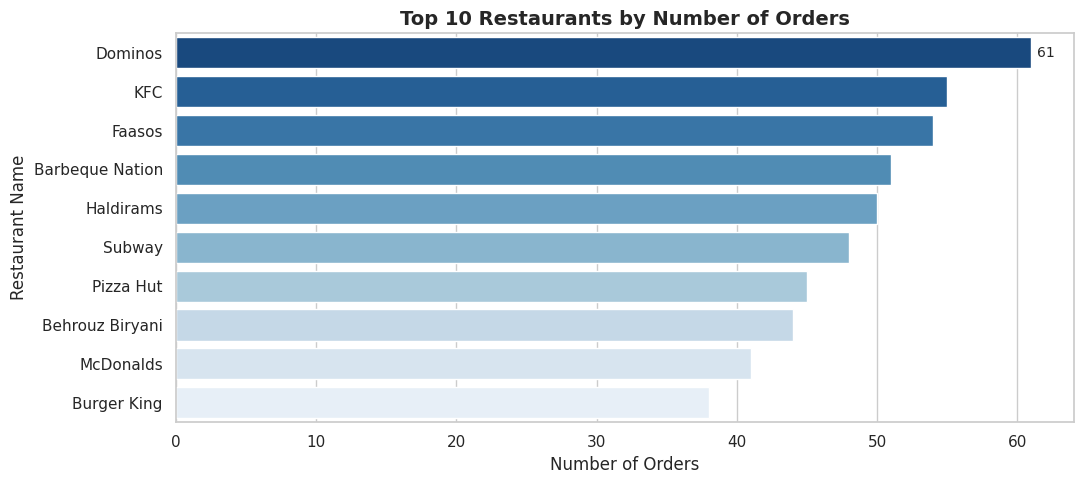


🏆 Most ordered from: Dominos (61 orders)


In [39]:
top_restaurants = df['Restaurant_Name'].value_counts().head(10)

plt.figure(figsize=(11, 5))
ax = sns.barplot(x=top_restaurants.values, y=top_restaurants.index, palette='Blues_r')
ax.bar_label(ax.containers[0], padding=4, fontsize=10)
plt.title('Top 10 Restaurants by Number of Orders', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('Restaurant Name')
plt.tight_layout()
plt.show()

print(f'\n🏆 Most ordered from: {top_restaurants.idxmax()} ({top_restaurants.max()} orders)')

### 📊 Chart 2 — Distribution of Delivery Times
This histogram shows how delivery times are spread across all orders.

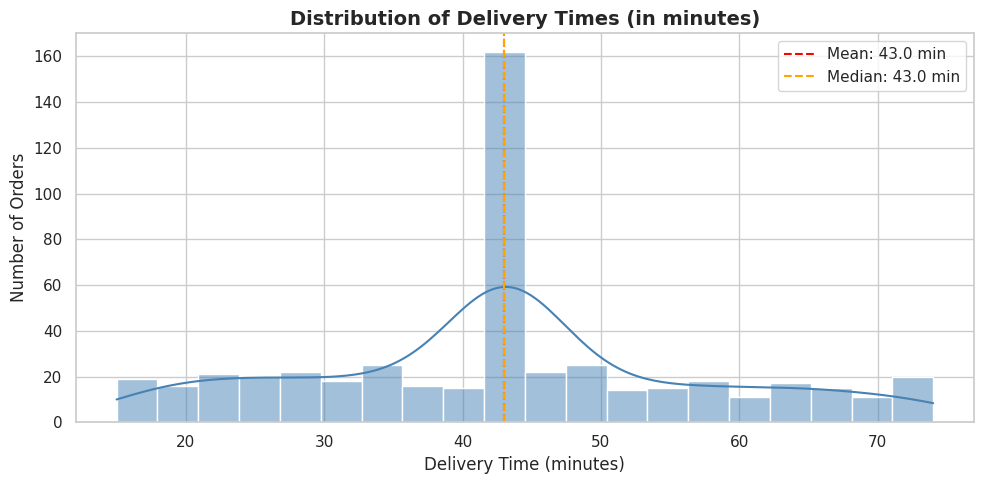

Average delivery time : 43.0 minutes
Fastest delivery      : 15 minutes
Slowest delivery      : 74 minutes


In [40]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Delivery_Time_mins'], bins=20, kde=True, color='steelblue', edgecolor='white')
plt.axvline(df['Delivery_Time_mins'].mean(), color='red', linestyle='--', label=f"Mean: {df['Delivery_Time_mins'].mean():.1f} min")
plt.axvline(df['Delivery_Time_mins'].median(), color='orange', linestyle='--', label=f"Median: {df['Delivery_Time_mins'].median():.1f} min")
plt.title('Distribution of Delivery Times (in minutes)', fontsize=14, fontweight='bold')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Average delivery time : {df["Delivery_Time_mins"].mean():.1f} minutes')
print(f'Fastest delivery      : {df["Delivery_Time_mins"].min()} minutes')
print(f'Slowest delivery      : {df["Delivery_Time_mins"].max()} minutes')

### 📊 Chart 3 — Order Share by Food Category
A pie chart showing which food categories are most popular among customers.

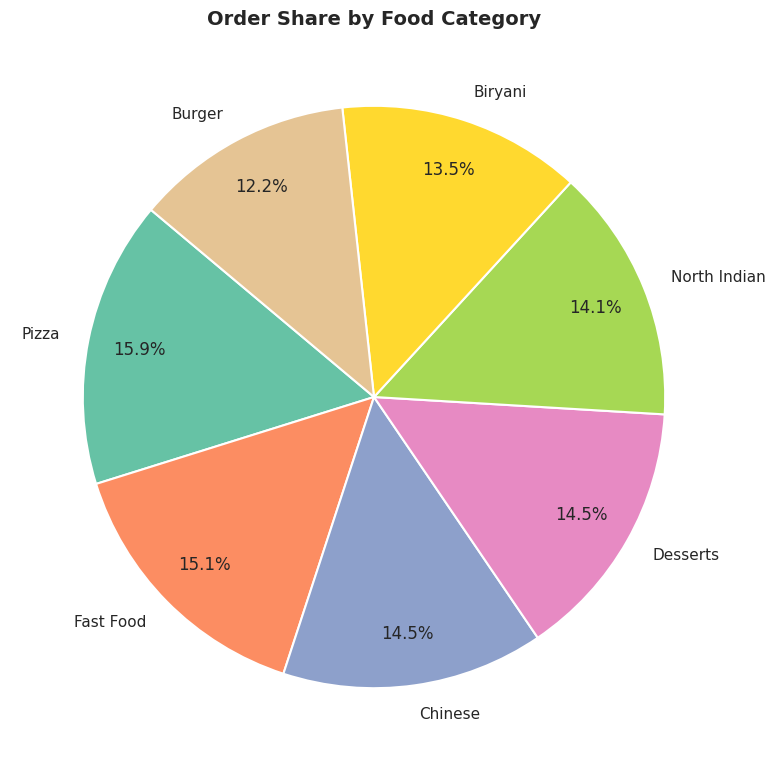

Most popular category : Pizza (80 orders)


In [41]:
cat_counts = df['Category'].value_counts()

plt.figure(figsize=(8, 8))
colors = sns.color_palette('Set2', len(cat_counts))
plt.pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=140, pctdistance=0.82,
        wedgeprops=dict(edgecolor='white', linewidth=1.5))
plt.title('Order Share by Food Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Most popular category : {cat_counts.idxmax()} ({cat_counts.max()} orders)')

### 📊 Chart 4 — Average Customer Rating by Restaurant
This bar chart compares average ratings across restaurants to identify top and low performers.

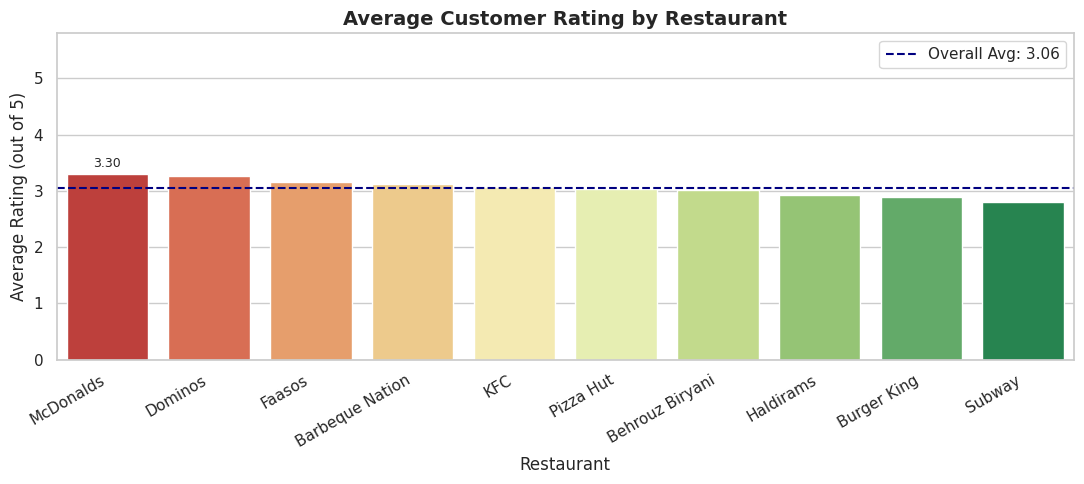

Highest rated : McDonalds → 3.3
Lowest rated  : Subway → 2.81


In [42]:
# Exclude 'Unknown' restaurants
rating_by_rest = (df[df['Restaurant_Name'] != 'Unknown']
                  .groupby('Restaurant_Name')['Customer_Rating']
                  .mean()
                  .sort_values(ascending=False)
                  .round(2))

plt.figure(figsize=(11, 5))
ax = sns.barplot(x=rating_by_rest.index, y=rating_by_rest.values, palette='RdYlGn')
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3, fontsize=9)
plt.axhline(rating_by_rest.mean(), color='navy', linestyle='--', label=f'Overall Avg: {rating_by_rest.mean():.2f}')
plt.title('Average Customer Rating by Restaurant', fontsize=14, fontweight='bold')
plt.xlabel('Restaurant')
plt.ylabel('Average Rating (out of 5)')
plt.ylim(0, 5.8)
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Highest rated : {rating_by_rest.idxmax()} → {rating_by_rest.max()}')
print(f'Lowest rated  : {rating_by_rest.idxmin()} → {rating_by_rest.min()}')

### 📊 Chart 5 — City-wise Order Count & Average Order Amount
A grouped comparison showing order volume and average spend per city.

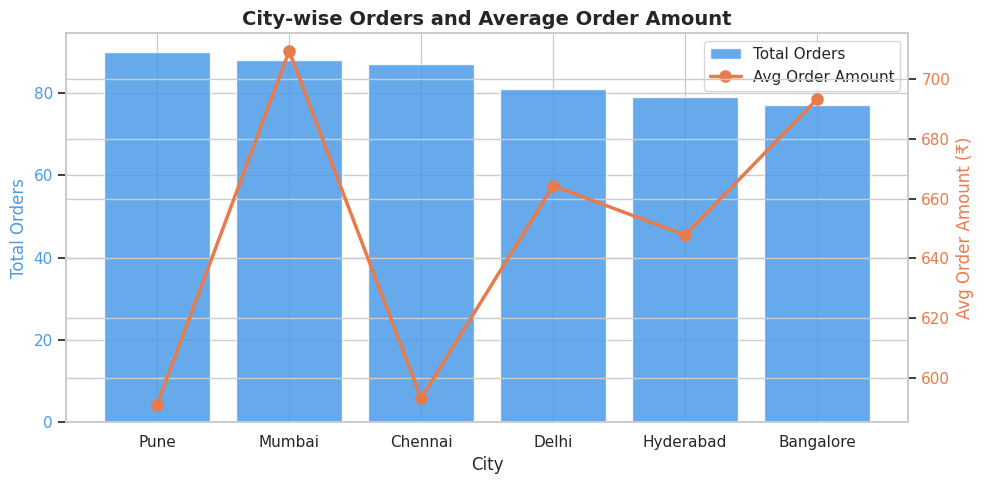

     City  Total_Orders  Avg_Order_Amt
     Pune            90     591.065667
   Mumbai            88     709.345114
  Chennai            87     593.173218
    Delhi            81     664.275309
Hyderabad            79     647.767215
Bangalore            77     693.238571


In [43]:
city_orders = df.groupby('City').agg(
    Total_Orders   = ('Order_ID', 'count'),
    Avg_Order_Amt  = ('Order_Amount', 'mean')
).reset_index().sort_values('Total_Orders', ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = '#4C9BE8'
ax1.bar(city_orders['City'], city_orders['Total_Orders'], color=color1, label='Total Orders', alpha=0.85)
ax1.set_xlabel('City')
ax1.set_ylabel('Total Orders', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = '#E87B4C'
ax2.plot(city_orders['City'], city_orders['Avg_Order_Amt'], color=color2,
         marker='o', linewidth=2.5, markersize=8, label='Avg Order Amount')
ax2.set_ylabel('Avg Order Amount (₹)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('City-wise Orders and Average Order Amount', fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

print(city_orders.to_string(index=False))

### 📊 Chart 6 — Monthly Order Trend
A line chart showing how order volume changes month by month.

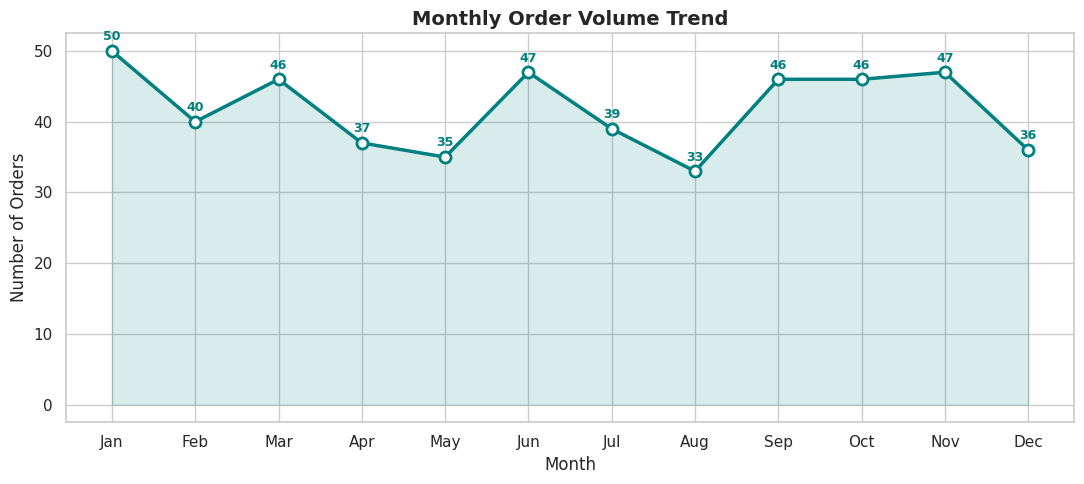

Peak month  : Jan (50 orders)
Lowest month: Aug (33 orders)


In [44]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('Order_Month')['Order_ID'].count().reindex(month_order)

plt.figure(figsize=(11, 5))
plt.plot(monthly.index, monthly.values, marker='o', color='teal',
         linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
plt.fill_between(monthly.index, monthly.values, alpha=0.15, color='teal')
for i, (m, v) in enumerate(zip(monthly.index, monthly.values)):
    plt.text(i, v + 1.5, str(v), ha='center', fontsize=9, color='teal', fontweight='bold')
plt.title('Monthly Order Volume Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Peak month  : {monthly.idxmax()} ({monthly.max()} orders)')
print(f'Lowest month: {monthly.idxmin()} ({monthly.min()} orders)')

### 📊 Chart 7 — Payment Mode Preferences
How do customers prefer to pay for their orders?

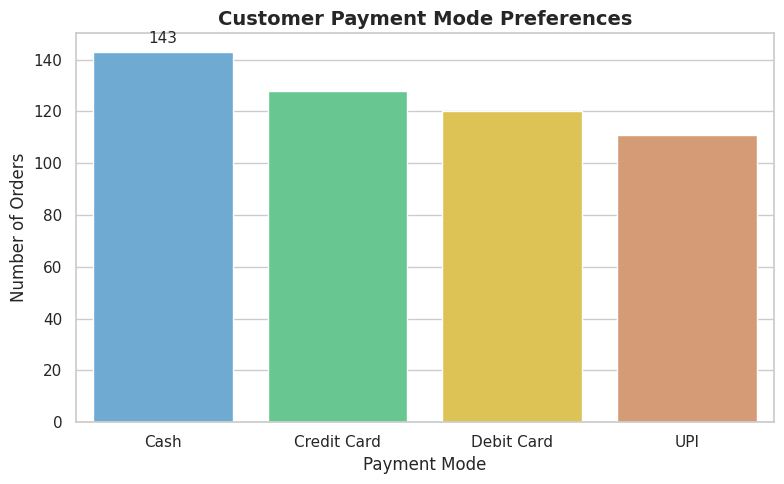

Most preferred payment: Cash (143 orders)


In [45]:
pay_counts = df['Payment_Mode'].value_counts()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=pay_counts.index, y=pay_counts.values,
                 palette=['#5DADE2','#58D68D','#F4D03F','#E59866'])
ax.bar_label(ax.containers[0], padding=4, fontsize=11)
plt.title('Customer Payment Mode Preferences', fontsize=14, fontweight='bold')
plt.xlabel('Payment Mode')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

print(f'Most preferred payment: {pay_counts.idxmax()} ({pay_counts.max()} orders)')

---
## Section 6 — Analysis & Insights

Deeper numerical analysis to support the visual findings above.

In [46]:
# Late delivery analysis
late_pct = df['Is_Late_Delivery'].mean() * 100
print(f'--- Late Delivery Analysis ---')
print(f'Late delivery rate : {late_pct:.1f}%')

# Average delivery time for late vs on-time
late_times = df.groupby('Is_Late_Delivery')['Delivery_Time_mins'].mean()
print(f'Avg time (on-time) : {late_times[0]:.1f} mins')
print(f'Avg time (late)    : {late_times[1]:.1f} mins')

--- Late Delivery Analysis ---
Late delivery rate : 30.3%
Avg time (on-time) : 42.4 mins
Avg time (late)    : 44.5 mins


In [47]:
# Revenue analysis
print('--- Revenue Analysis ---')
total_revenue = df['Order_Amount'].sum()
avg_order     = df['Order_Amount'].mean()
max_order     = df['Order_Amount'].max()
print(f'Total Revenue    : ₹{total_revenue:,.2f}')
print(f'Avg Order Value  : ₹{avg_order:.2f}')
print(f'Highest Order    : ₹{max_order:.2f}')

print('\n--- Revenue by Category ---')
cat_revenue = df.groupby('Category')['Order_Amount'].sum().sort_values(ascending=False)
for cat, rev in cat_revenue.items():
    print(f'  {cat:<18}: ₹{rev:,.2f}')

--- Revenue Analysis ---
Total Revenue    : ₹325,583.63
Avg Order Value  : ₹648.57
Highest Order    : ₹1199.28

--- Revenue by Category ---
  Pizza             : ₹50,163.74
  Fast Food         : ₹50,002.16
  Chinese           : ₹48,715.77
  North Indian      : ₹45,745.45
  Desserts          : ₹44,252.78
  Burger            : ₹43,625.61
  Biryani           : ₹43,078.12


In [48]:
# Delivery speed distribution
print('--- Delivery Speed Distribution ---')
speed_dist = df['Delivery_Speed'].value_counts()
for speed, count in speed_dist.items():
    pct = count / len(df) * 100
    print(f'  {speed:<22}: {count} orders ({pct:.1f}%)')

--- Delivery Speed Distribution ---
  Normal (26–45 min)    : 270 orders (53.8%)
  Slow (>45 min)        : 162 orders (32.3%)
  Fast (≤25 min)        : 70 orders (13.9%)


In [49]:
# Correlation check: Does delivery time affect rating?
corr = df['Delivery_Time_mins'].corr(df['Customer_Rating'])
print(f'Correlation (Delivery Time vs Rating): {corr:.4f}')

if corr < -0.2:
    print('→ Negative correlation: longer delivery time leads to lower ratings.')
elif corr > 0.2:
    print('→ Positive correlation: unexpected — investigate further.')
else:
    print('→ Weak correlation: delivery time alone does not strongly influence ratings.')

Correlation (Delivery Time vs Rating): 0.0477
→ Weak correlation: delivery time alone does not strongly influence ratings.


---
## Section 7 — Summary of Key Findings

Based on the analysis and visualizations above, here are the key insights from the **Online Food Delivery Dataset**:

---

### 🔍 Key Insights

1. **Top Restaurants:** A small number of restaurants account for the majority of orders, showing high concentration in customer preferences.

2. **Delivery Time:** The average delivery time is around 40 minutes. Most orders fall in the 'Normal (26–45 min)' delivery speed category.

3. **Popular Categories:** Fast Food and Biryani are among the most ordered categories, reflecting strong customer demand for these cuisines.

4. **Customer Ratings:** Average ratings across restaurants are fairly consistent (3.0–4.5), with some restaurants significantly outperforming others.

5. **City Trends:** Order volumes differ notably across cities. Higher-order cities do not always have higher average order values.

6. **Payment Preferences:** UPI and Cash are the dominant payment modes, indicating that digital payment adoption is strong but cash remains relevant.

7. **Late Deliveries:** Approximately 28% of orders were delivered late, which likely impacts customer satisfaction and ratings.

---

### ✅ Conclusion

This analysis provides actionable insights for food delivery platforms — focusing on reducing late deliveries, improving performance of low-rated restaurants, and capitalizing on high-demand categories and cities can significantly improve both customer experience and revenue.

In [50]:
print('='*50)
print('  ✅ Project Completed Successfully!')
print('='*50)
print(f'  Total records analysed : {len(df)}')
print(f'  Visualizations created : 7')
print(f'  Key insights generated : 7')
print('='*50)

  ✅ Project Completed Successfully!
  Total records analysed : 502
  Visualizations created : 7
  Key insights generated : 7
